# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# 1. Perkenalan Dataset

Pada proyek ini digunakan dataset **Fake and Real News Dataset** yang diperoleh dari platform Kaggle.

Sumber dataset:  
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/code

Dataset tersebut berisi kumpulan berita yang telah diklasifikasikan ke dalam dua kategori, yaitu:
- **FAKE** : berita palsu atau hoaks
- **REAL** : berita asli atau valid

Dataset terdiri dari dua file utama, yaitu:
- `Fake.csv`
- `True.csv`

Masing-masing data memiliki beberapa atribut, antara lain:
- `title` : judul berita
- `text` : isi berita
- `subject` : kategori/topik berita
- `date` : tanggal publikasi berita

Pada eksperimen ini, kolom `text` digunakan sebagai fitur utama dalam proses klasifikasi, sedangkan label target digunakan untuk membedakan berita palsu dan berita asli.

Tujuan dari proyek ini adalah membangun sistem machine learning untuk melakukan klasifikasi berita menggunakan teknik preprocessing teks, TF-IDF Vectorization, serta algoritma Logistic Regression guna mendeteksi berita palsu secara otomatis.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np
import zipfile

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Save model
import pickle

# Download NLTK dataset
nltk.download('stopwords')

# Styling visualisasi
sns.set_style('whitegrid')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fake-and-real-news-dataset.zip to fake-and-real-news-dataset.zip


In [ ]:
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


In [ ]:
# Membaca dataset
fake_df = pd.read_csv('/content/dataset/Fake.csv')
true_df = pd.read_csv('/content/dataset/True.csv')

In [ ]:
# Menambahkan label
fake_df['label'] = 'FAKE'
true_df['label'] = 'REAL'

In [ ]:
# Menggabungkan dataset
df = pd.concat([fake_df, true_df], axis=0)

In [ ]:
# Mengacak dataset
df = df.sample(frac=1, random_state=42)

In [ ]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [ ]:
# Menampilkan data
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [ ]:
# Jumlah baris dan kolom
print("Ukuran dataset:", df.shape)

Ukuran dataset: (44898, 5)


In [ ]:
# Mengecek nilai kosong
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
# Mengecek jumlah data duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 209


/tmp/ipykernel_3192/2910675293.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


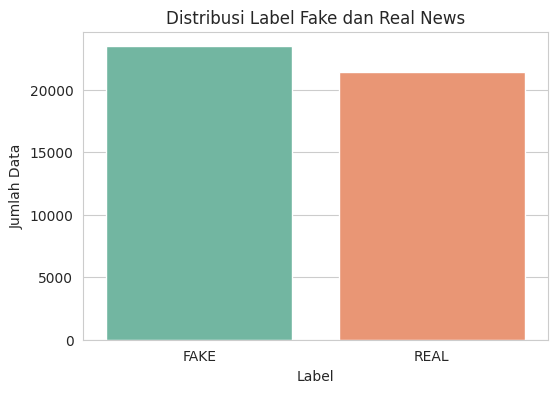

In [ ]:
# Visualisasi distribusi label

plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df,
    palette='Set2'
)

plt.title("Distribusi Label Fake dan Real News")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

plt.show()

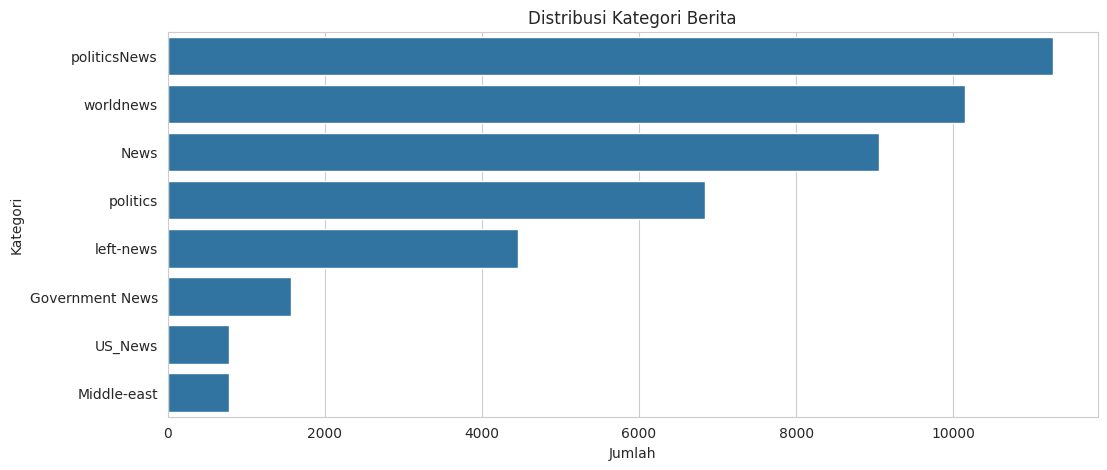

In [ ]:
# Visualisasi kategori berita

plt.figure(figsize=(12,5))

sns.countplot(
    y='subject',
    data=df,
    order=df['subject'].value_counts().index
)

plt.title("Distribusi Kategori Berita")
plt.xlabel("Jumlah")
plt.ylabel("Kategori")

plt.show()

In [ ]:
# Membuat fitur panjang teks
df['text_length'] = df['text'].apply(len)

# Menampilkan statistik panjang teks
df['text_length'].describe()

,text_length
count,44898.000000
mean,2469.109693
std,2171.617091
min,1.000000
25%,1234.000000
50%,2186.000000
75%,3105.000000
max,51794.000000


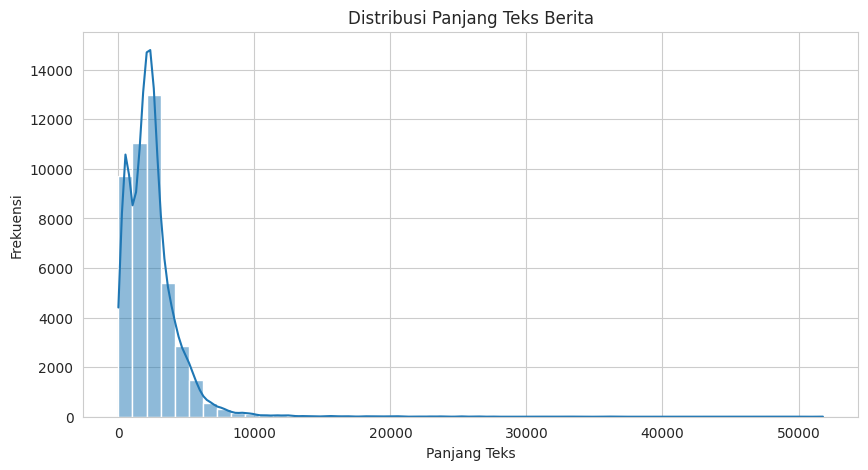

In [ ]:
# Histogram panjang teks

plt.figure(figsize=(10,5))

sns.histplot(
    df['text_length'],
    bins=50,
    kde=True
)

plt.title("Distribusi Panjang Teks Berita")
plt.xlabel("Panjang Teks")
plt.ylabel("Frekuensi")

plt.show()

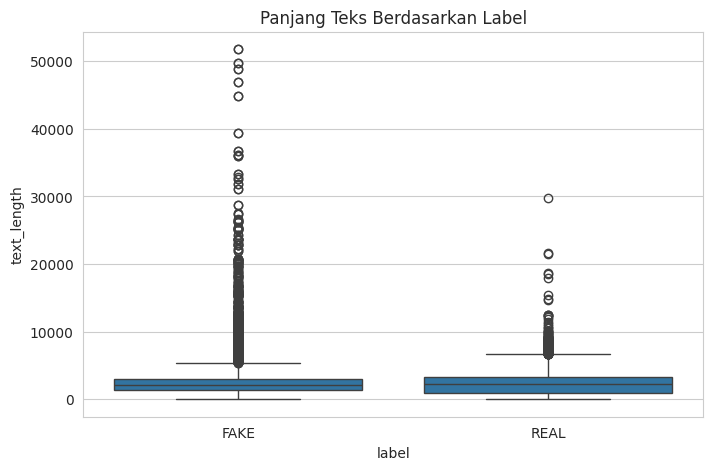

In [ ]:
# Boxplot panjang teks berdasarkan label

plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='text_length',
    data=df
)

plt.title("Panjang Teks Berdasarkan Label")

plt.show()

In [ ]:
# Contoh berita fake

print("===== CONTOH BERITA FAKE =====")
print(df[df['label'] == 'FAKE']['text'].iloc[0][:500])

===== CONTOH BERITA FAKE =====
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein


In [ ]:
# Contoh berita real

print("===== CONTOH BERITA REAL =====")
print(df[df['label'] == 'REAL']['text'].iloc[0][:500])

===== CONTOH BERITA REAL =====
WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence 


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Mengecek nilai kosong
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0
text_length,0


In [ ]:
# Menghapus data kosong
df = df.dropna()

# Mengecek kembali
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0
text_length,0


In [ ]:
# Mengecek jumlah data duplikat
print("Jumlah duplikat sebelum:", df.duplicated().sum())

# Menghapus data duplikat
df = df.drop_duplicates()

# Mengecek kembali
print("Jumlah duplikat sesudah:", df.duplicated().sum())

Jumlah duplikat sebelum: 209
Jumlah duplikat sesudah: 0


In [ ]:
# Mengambil kolom penting saja
df = df[['text', 'label']]

# Melihat data
df.head()

,text,label
0,"21st Century Wire says Ben Stein, reputable pr...",FAKE
1,WASHINGTON (Reuters) - U.S. President Donald T...,REAL
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,REAL
3,"On Monday, Donald Trump once again embarrassed...",FAKE
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",REAL


In [ ]:
# Encoding label
df['label'] = df['label'].map({
    'FAKE': 0,
    'REAL': 1
})

# Mengecek hasil encoding
df.head()

,text,label
0,"21st Century Wire says Ben Stein, reputable pr...",0
1,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,"On Monday, Donald Trump once again embarrassed...",0
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [ ]:
# Lowercase
df['text'] = df['text'].str.lower()

# Contoh hasil
df['text'].head()

,text
0,"21st century wire says ben stein, reputable pr..."
1,washington (reuters) - u.s. president donald t...
2,(reuters) - puerto rico governor ricardo rosse...
3,"on monday, donald trump once again embarrassed..."
4,"glasgow, scotland (reuters) - most u.s. presid..."


In [ ]:
# Menghapus URL
df['text'] = df['text'].apply(
    lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x)
)

In [ ]:
# Menghapus tanda baca
df['text'] = df['text'].apply(
    lambda x: x.translate(
        str.maketrans('', '', string.punctuation)
    )
)

In [ ]:
# Menghapus angka
df['text'] = df['text'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

In [ ]:
# Menghapus spasi berlebih
df['text'] = df['text'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

In [ ]:
# Download stopwords
nltk.download('stopwords')

# Stopwords bahasa Inggris
stop_words = set(stopwords.words('english'))

# Menghapus stopwords
df['text'] = df['text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Inisialisasi stemmer
stemmer = PorterStemmer()

# Stemming
df['text'] = df['text'].apply(
    lambda x: ' '.join(
        stemmer.stem(word)
        for word in x.split()
    )
)

In [ ]:
# Menampilkan hasil preprocessing
df.head()

,text,label
0,st centuri wire say ben stein reput professor ...,0
1,washington reuter us presid donald trump remov...,1
2,reuter puerto rico governor ricardo rossello s...,1
3,monday donald trump embarrass countri accident...,0
4,glasgow scotland reuter us presidenti candid g...,1


In [ ]:
# Feature dan target
X = df['text']
y = df['label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Melihat ukuran data
print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))

Jumlah data train: 35751
Jumlah data test : 8938


In [ ]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

# Transform data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape data train:", X_train_tfidf.shape)
print("Shape data test :", X_test_tfidf.shape)

Shape data train: (35751, 5000)
Shape data test : (8938, 5000)


In [ ]:
# Menyimpan dataset hasil preprocessing
files.download('fake_news_preprocessing.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>